### **This file performs 5 fold CV on the combined (RAVDESS, CREMA-D, TESS) dataset WITHOUT performing data augmentation**

In [1]:
import numpy as np
import time
from datetime import datetime

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

## Load Data

In [3]:
data_folder = "../../datasets_combined_no_augmented"

X_train_full = np.load(f"{data_folder}/X_deep_train.npy")
y_train_full = np.load(f"{data_folder}/y_deep_train.npy")

X_test = np.load(f"{data_folder}/X_deep_test.npy")
y_test = np.load(f"{data_folder}/y_deep_test.npy")

num_classes = len(np.unique(y_train_full))

### Define a function to get current timestamp

In [4]:
def now():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

## Define function to create model

In [5]:
import tensorflow as tf
from tensorflow.keras import layers as L

# function to re-initialize a fresh CNN–BiLSTM model for each fold.
def create_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        L.Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=input_shape),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),

        L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),
        L.Dropout(0.2),

        L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),
        L.Dropout(0.2),

        L.Bidirectional(L.LSTM(128, return_sequences=False)),
        L.Dropout(0.3),

        L.Dense(256, activation='relu'),
        L.Dropout(0.3),
        L.Dense(128, activation='relu'),

        L.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Perform CV

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
cv_accuracies = []
all_histories = []

for train_idx, val_idx in skf.split(X_train_full, y_train_full):

    print("\n==============================================================")
    print(f"[{now()}] ✅ STARTING FOLD {fold}")
    print("==============================================================")

    # -----------------------------------------------------------
    # SPLIT FOLD DATA
    # -----------------------------------------------------------
    X_tr = X_train_full[train_idx]
    y_tr = y_train_full[train_idx]

    X_val = X_train_full[val_idx]
    y_val = y_train_full[val_idx]

    print(f"[{now()}] Train shape: {X_tr.shape}, Val shape: {X_val.shape}")

    # -----------------------------------------------------------
    # NORMALIZATION (fit ONLY on training fold)
    # -----------------------------------------------------------
    print(f"[{now()}] 🔄 Normalizing features...")
    t0 = time.time()
    mean = X_tr.mean(axis=(0, 1), keepdims=True)
    std = X_tr.std(axis=(0, 1), keepdims=True) + 1e-8
    X_tr = (X_tr - mean) / std
    X_val = (X_val - mean) / std
    print(f"[{now()}] ✅ Normalization done. Time: {time.time() - t0:.2f}s")

    # -----------------------------------------------------------
    # ONE-HOT ENCODING
    # -----------------------------------------------------------
    y_tr_cat = to_categorical(y_tr - 1, num_classes)
    y_val_cat = to_categorical(y_val - 1, num_classes)

    # -----------------------------------------------------------
    # CLASS WEIGHTS
    # -----------------------------------------------------------
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(enumerate(cw))

    # -----------------------------------------------------------
    # BUILD MODEL
    # -----------------------------------------------------------
    print(f"[{now()}] 🔄 Building model...")
    t0 = time.time()
    model = create_model(
        input_shape=(X_tr.shape[1], X_tr.shape[2]),
        num_classes=num_classes
    )
    print(f"[{now()}] ✅ Model built. Time: {time.time() - t0:.2f}s")

    # -----------------------------------------------------------
    # CALLBACKS
    # -----------------------------------------------------------
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
        ModelCheckpoint(
            filepath=f"best_model_fold_{fold}.keras",
            monitor="val_accuracy",
            save_best_only=True
        )
    ]

    # -----------------------------------------------------------
    # TRAINING
    # -----------------------------------------------------------
    print(f"[{now()}] 🚀 Training model (Fold {fold})...")
    t0 = time.time()

    history = model.fit(
        X_tr, y_tr_cat,
        validation_data=(X_val, y_val_cat),
        epochs=50,
        batch_size=64,
        class_weight=class_weights,
        verbose=1,
        callbacks=callbacks
    )

    duration = time.time() - t0
    print(f"[{now()}] ✅ Training complete for Fold {fold}. Time: {duration:.2f}s")

    # -----------------------------------------------------------
    # RECORD BEST VAL ACCURACY
    # -----------------------------------------------------------
    best_acc = max(history.history["val_accuracy"])
    cv_accuracies.append(best_acc)
    all_histories.append(history.history)

    print(f"[{now()}] ✅ Fold {fold} Best Val Accuracy: {best_acc:.4f}")

    fold += 1


[2025-11-09 23:22:33] ✅ STARTING FOLD 1
[2025-11-09 23:22:33] Train shape: (6816, 455, 92), Val shape: (1704, 455, 92)
[2025-11-09 23:22:33] 🔄 Normalizing features...
[2025-11-09 23:22:37] ✅ Normalization done. Time: 3.23s
[2025-11-09 23:22:37] 🔄 Building model...
[2025-11-09 23:22:37] ✅ Model built. Time: 0.12s
[2025-11-09 23:22:37] 🚀 Training model (Fold 1)...


c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 284ms/step - accuracy: 0.3467 - loss: 1.5302 - val_accuracy: 0.3715 - val_loss: 1.5421 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 311ms/step - accuracy: 0.5233 - loss: 1.1369 - val_accuracy: 0.5440 - val_loss: 1.1654 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 337ms/step - accuracy: 0.5619 - loss: 1.0463 - val_accuracy: 0.5558 - val_loss: 1.1542 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 346ms/step - accuracy: 0.5805 - loss: 0.9948 - val_accuracy: 0.5786 - val_loss: 1.0741 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 307ms/step - accuracy: 0.6112 - loss: 0.9381 - val_accuracy: 0.5933 - val_loss: 1.0601 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 314ms/step - accuracy: 0.6408 - loss: 0.8780 - val_accuracy: 0.5980 - val_loss: 1.0961 - learning_rate: 0.0010
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 310ms/step - accuracy: 0.6

c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[2025-11-09 23:35:09] ✅ Model built. Time: 0.28s
[2025-11-09 23:35:09] 🚀 Training model (Fold 2)...
Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 318ms/step - accuracy: 0.3253 - loss: 1.5531 - val_accuracy: 0.4460 - val_loss: 1.4252 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 306ms/step - accuracy: 0.4953 - loss: 1.1758 - val_accuracy: 0.5346 - val_loss: 1.1785 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 313ms/step - accuracy: 0.5474 - loss: 1.0740 - val_accuracy: 0.5575 - val_loss: 1.0974 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 311ms/step - accuracy: 0.5767 - loss: 0.9877 - val_accuracy: 0.5898 - val_loss: 1.0552 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 309ms/step - accuracy: 0.6177 - loss: 0.9392 - val_accuracy: 0.6092 - val_loss: 1.0026 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 309ms/step - accuracy: 0.6354 - loss: 0.8930 - val_accuracy: 0.6127 - val_loss: 0

...

[2025-11-09 23:45:19] ✅ Model built. Time: 0.27s
[2025-11-09 23:45:19] 🚀 Training model (Fold 3)...
Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 54s 413ms/step - accuracy: 0.3330 - loss: 1.5302 - val_accuracy: 0.4173 - val_loss: 1.3815 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 40s 377ms/step - accuracy: 0.5054 - loss: 1.1610 - val_accuracy: 0.5728 - val_loss: 1.0913 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - accuracy: 0.5443 - loss: 1.0548 - val_accuracy: 0.5651 - val_loss: 1.0977 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 383ms/step - accuracy: 0.5783 - loss: 1.0029 - val_accuracy: 0.5968 - val_loss: 1.0080 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 42s 392ms/step - accuracy: 0.5952 - loss: 0.9515 - val_accuracy: 0.6080 - val_loss: 1.0111 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 40s 375ms/step - accuracy: 0.6257 - loss: 0.8988 - val_accuracy: 0.6144 - val_loss: 0

c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[2025-11-09 23:59:46] ✅ Model built. Time: 0.33s
[2025-11-09 23:59:46] 🚀 Training model (Fold 4)...
Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 370ms/step - accuracy: 0.3380 - loss: 1.5244 - val_accuracy: 0.3316 - val_loss: 1.7674 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 350ms/step - accuracy: 0.5109 - loss: 1.1605 - val_accuracy: 0.4665 - val_loss: 1.3090 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 346ms/step - accuracy: 0.5459 - loss: 1.0634 - val_accuracy: 0.5610 - val_loss: 1.0878 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 351ms/step - accuracy: 0.5716 - loss: 1.0196 - val_accuracy: 0.5921 - val_loss: 1.0384 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 347ms/step - accuracy: 0.5946 - loss: 0.9702 - val_accuracy: 0.5874 - val_loss: 1.0244 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 347ms/step - accuracy: 0.6272 - loss: 0.8983 - val_accuracy: 0.6227 - val_loss: 0

c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[2025-11-10 00:13:46] ✅ Model built. Time: 0.28s
[2025-11-10 00:13:46] 🚀 Training model (Fold 5)...
Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 355ms/step - accuracy: 0.3228 - loss: 1.5719 - val_accuracy: 0.3950 - val_loss: 1.4769 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 342ms/step - accuracy: 0.4950 - loss: 1.1777 - val_accuracy: 0.5241 - val_loss: 1.2068 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 339ms/step - accuracy: 0.5431 - loss: 1.0774 - val_accuracy: 0.5816 - val_loss: 1.0590 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 339ms/step - accuracy: 0.5801 - loss: 1.0054 - val_accuracy: 0.5915 - val_loss: 1.0486 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 340ms/step - accuracy: 0.5984 - loss: 0.9597 - val_accuracy: 0.6197 - val_loss: 0.9672 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 338ms/step - accuracy: 0.6137 - loss: 0.9491 - val_accuracy: 0.6250 - val_loss: 0

### CV summary

In [8]:
print("\n==============================================================")
print(f"✅ CROSS-VALIDATION COMPLETE")
print(f"✅ Mean Val Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print("==============================================================")


✅ CROSS-VALIDATION COMPLETE
✅ Mean Val Accuracy: 0.7012 ± 0.0162


### Plot results

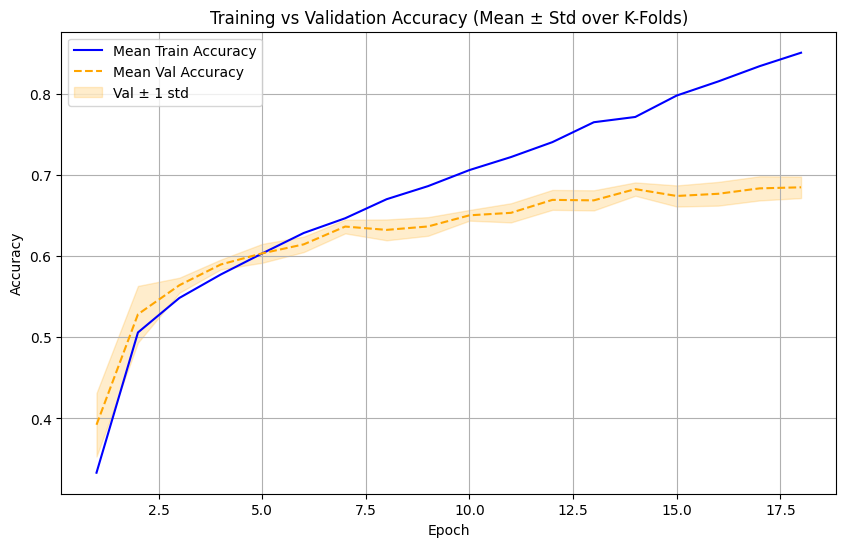

In [11]:
import matplotlib.pyplot as plt

# --- Compute means and stds ---
mean_acc = acc.mean(axis=0)
std_acc  = acc.std(axis=0)

mean_val_acc = val_acc.mean(axis=0)
std_val_acc  = val_acc.std(axis=0)

epochs = range(1, min_epochs + 1)

plt.figure(figsize=(10, 6))

# Mean training accuracy
plt.plot(epochs, mean_acc, label='Mean Train Accuracy', color='blue')

# Mean validation accuracy
plt.plot(epochs, mean_val_acc, label='Mean Val Accuracy', color='orange', linestyle='--')

# Shaded std band for validation accuracy
plt.fill_between(
    epochs,
    mean_val_acc - std_val_acc,
    mean_val_acc + std_val_acc,
    color='orange',
    alpha=0.2,
    label='Val ± 1 std'
)

plt.title("Training vs Validation Accuracy (Mean ± Std over K-Folds)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

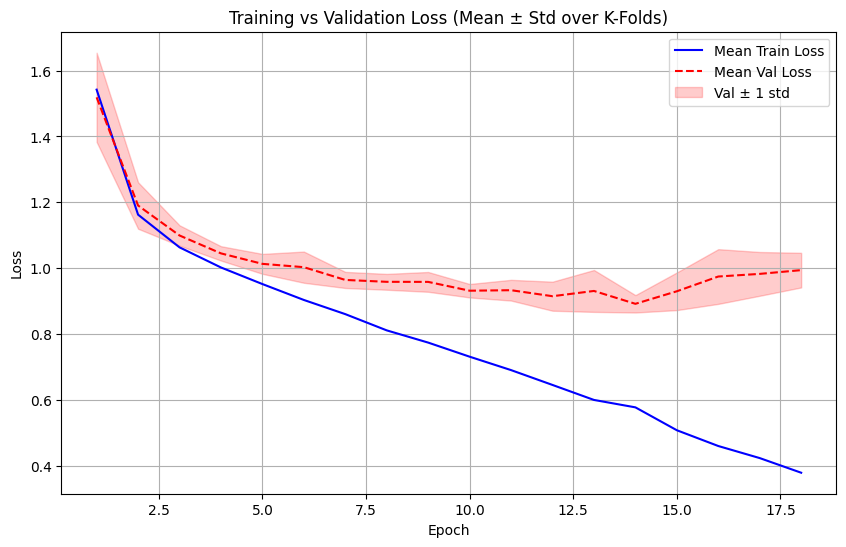

In [12]:
# --- Compute means and stds ---
mean_loss = loss.mean(axis=0)
std_loss  = loss.std(axis=0)

mean_val_loss = val_loss.mean(axis=0)
std_val_loss  = val_loss.std(axis=0)

epochs = range(1, min_epochs + 1)

plt.figure(figsize=(10, 6))

# Mean training loss
plt.plot(epochs, mean_loss, label='Mean Train Loss', color='blue')

# Mean validation loss
plt.plot(epochs, mean_val_loss, label='Mean Val Loss', color='red', linestyle='--')

# Shaded std band for validation loss
plt.fill_between(
    epochs,
    mean_val_loss - std_val_loss,
    mean_val_loss + std_val_loss,
    color='red',
    alpha=0.2,
    label='Val ± 1 std'
)

plt.title("Training vs Validation Loss (Mean ± Std over K-Folds)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Evaluate test set

#### Train best model

In [13]:
# Compute normalization stats from FULL TRAINING SET
train_mean = X_train_full.mean(axis=(0, 1), keepdims=True)
train_std  = X_train_full.std(axis=(0, 1), keepdims=True) + 1e-8

# Normalize training and test sets
X_train_norm = (X_train_full - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

# One-hot encode labels
y_train_cat = to_categorical(y_train_full - 1, num_classes)
y_test_cat  = to_categorical(y_test - 1, num_classes)

In [14]:
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_full),
    y=y_train_full
)
class_weights = dict(zip(np.unique(y_train_full) - 1, cw))

In [15]:
model_final = create_model(
    input_shape=(X_train_norm.shape[1], X_train_norm.shape[2]),
    num_classes=num_classes
)

c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
callbacks_final = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "final_model_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [17]:
history_final = model_final.fit(
    X_train_norm,
    y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,   # recommended small val split
    class_weight=class_weights,
    callbacks=callbacks_final,
    verbose=1
)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 411ms/step - accuracy: 0.3486 - loss: 1.5008 - val_accuracy: 0.4613 - val_loss: 1.3695 - learning_rate: 0.0010
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 48s 398ms/step - accuracy: 0.5168 - loss: 1.1392 - val_accuracy: 0.5657 - val_loss: 1.1224 - learning_rate: 0.0010
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 379ms/step - accuracy: 0.5627 - loss: 1.0440 - val_accuracy: 0.5516 - val_loss: 1.1237 - learning_rate: 0.0010
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 382ms/step - accuracy: 0.5799 - loss: 0.9997 - val_accuracy: 0.5904 - val_loss: 1.0555 - learning_rate: 0.0010
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 385ms/step - accuracy: 0.6101 - loss: 0.9369 - val_accuracy: 0.5833 - val_loss: 1.0472 - learning_rate: 0.0010
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 387ms/step - accuracy: 0.6346 - loss: 0.8871 - val_accuracy: 0.6362 - val_loss: 0.9539 - learning_rate: 0.0010
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 83s 393ms/step - accuracy: 0.6

#### Get model outputs

In [19]:
# Extract Loss and Accuracy
test_loss, test_acc = model_final.evaluate(X_test_norm, y_test_cat, verbose=1)

# Predicted probabilities
y_pred_probs = model_final.predict(X_test_norm)

# Predicted class indices (1..num_classes)
y_pred = np.argmax(y_pred_probs, axis=1) + 1

# True class indices (already 1..num_classes)
y_true = y_test

print("\n=====================================")
print(f"✅ FINAL TEST ACCURACY: {test_acc:.4f}")
print(f"✅ FINAL TEST LOSS: {test_loss:.4f}")
print("=====================================\n")


67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.6770 - loss: 0.8636
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step

✅ FINAL TEST ACCURACY: 0.6770
✅ FINAL TEST LOSS: 0.8636



#### Confusion Matrix

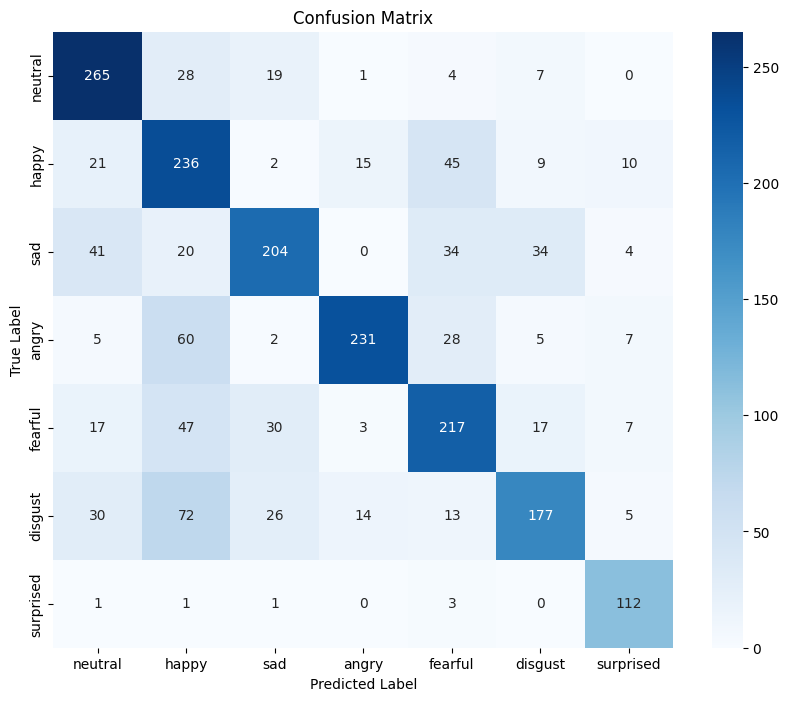

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

emotion_labels = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### Classification Report

In [22]:
from sklearn.metrics import classification_report
emotion_labels = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

print("\n========== Classification Report ==========\n")
print(classification_report(y_true, y_pred, target_names=emotion_labels))


========== Classification Report ==========

              precision    recall  f1-score   support

     neutral       0.70      0.82      0.75       324
       happy       0.51      0.70      0.59       338
         sad       0.72      0.61      0.66       337
       angry       0.88      0.68      0.77       338
     fearful       0.63      0.64      0.64       338
     disgust       0.71      0.53      0.60       337
   surprised       0.77      0.95      0.85       118

    accuracy                           0.68      2130
   macro avg       0.70      0.70      0.69      2130
weighted avg       0.69      0.68      0.68      2130



#### Per class accuracy heatmap

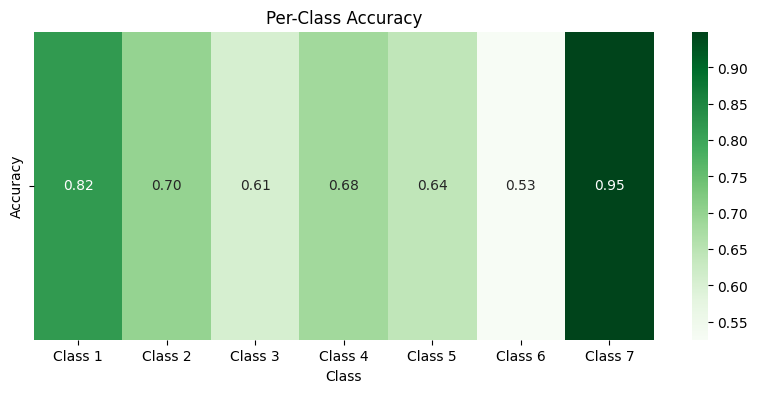

In [23]:
class_names = [f"Class {i}" for i in range(1, num_classes+1)]

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 4))
sns.heatmap(per_class_accuracy.reshape(1, -1), annot=True, cmap="Greens", fmt=".2f",
            xticklabels=class_names, yticklabels=["Accuracy"])
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.show()

#### ROC Curves

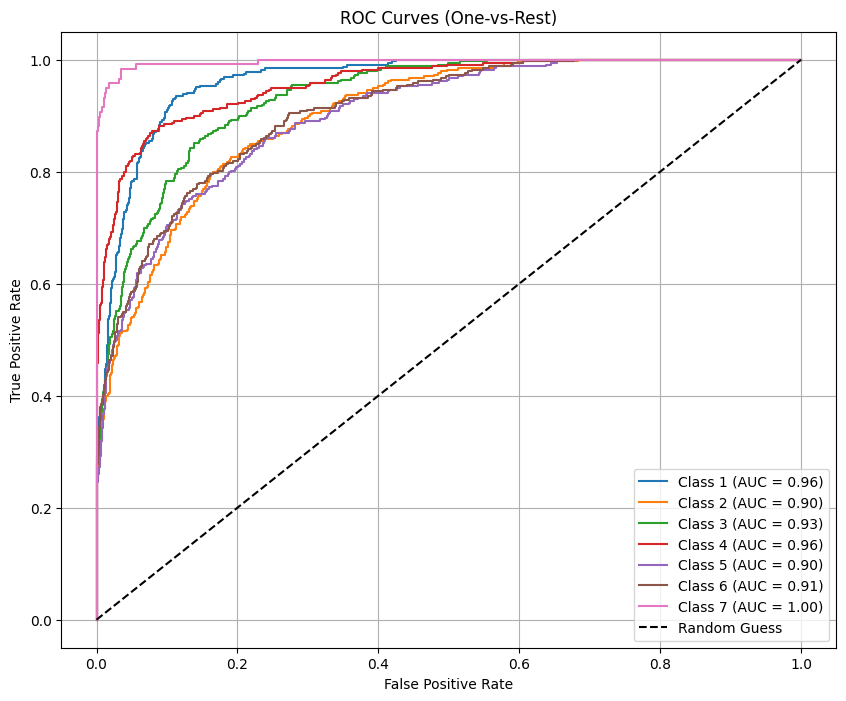

In [24]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert to one-hot (binarized)
y_test_bin = label_binarize(y_true, classes=np.arange(1, num_classes+1))

plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i+1} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()
